In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# --- PHẦN 1: CÀI ĐẶT MÔI TRƯỜNG ---
import os

# 1. Tắt WandB
os.environ["WANDB_DISABLED"] = "true"

# 2. Cài đặt thư viện
print(">>> Đang cài đặt thư viện...")
os.system('pip install transformers datasets scikit-learn pandas torch accelerate wordcloud seaborn matplotlib -q')

>>> Đang cài đặt thư viện...


0

In [8]:
# --- PHẦN 2: IMPORT THƯ VIỆN & CẤU HÌNH FONT AN TOÀN ---
import pandas as pd
import numpy as np
import torch
import re
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset

# Cấu hình giao diện biểu đồ
plt.style.use('ggplot')
pd.options.mode.chained_assignment = None

# --- [FIX LỖI] CHỌN FONT CHỮ CÓ SẴN TRÊN COLAB ---
# Thay vì tải, ta dùng luôn font hệ thống để tránh lỗi file hỏng
FONT_PATH = "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf"
if not os.path.exists(FONT_PATH):
    FONT_PATH = None # Nếu xui lắm không có thì dùng mặc định (có thể hơi lỗi font nhưng không crash)

print(f"✅ Đã cấu hình font chữ: {FONT_PATH}")

✅ Đã cấu hình font chữ: /usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf



>>> 1. ĐỌC DỮ LIỆU & EDA...
   - Tổng số mẫu ban đầu: 1524
   - Số mẫu sau khi lọc: 1493


/tmp/ipython-input-1225956721.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_filtered['label'], order=df_filtered['label'].value_counts().index, palette='viridis')


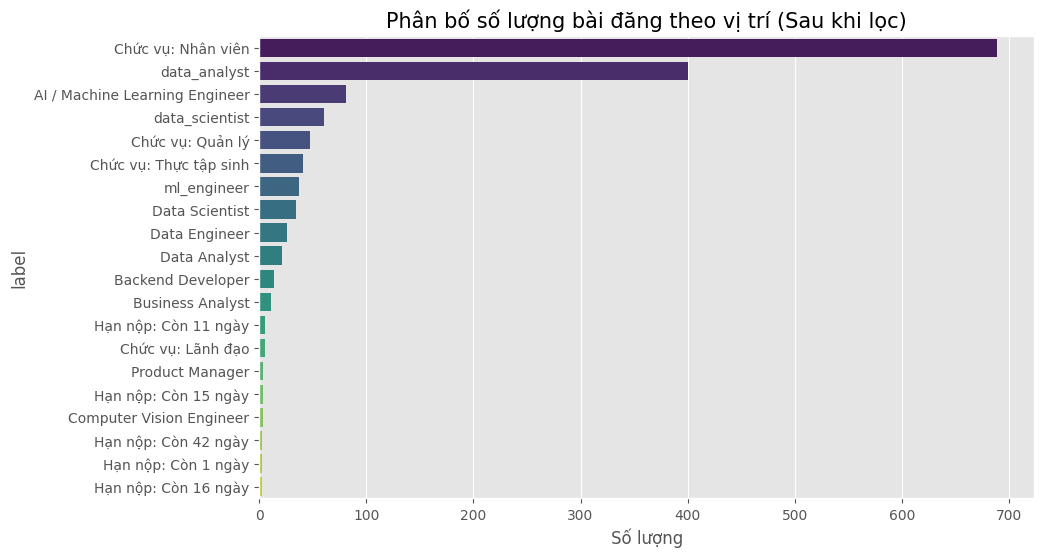

   - Đang vẽ WordCloud cho Top 4 nhóm ngành...


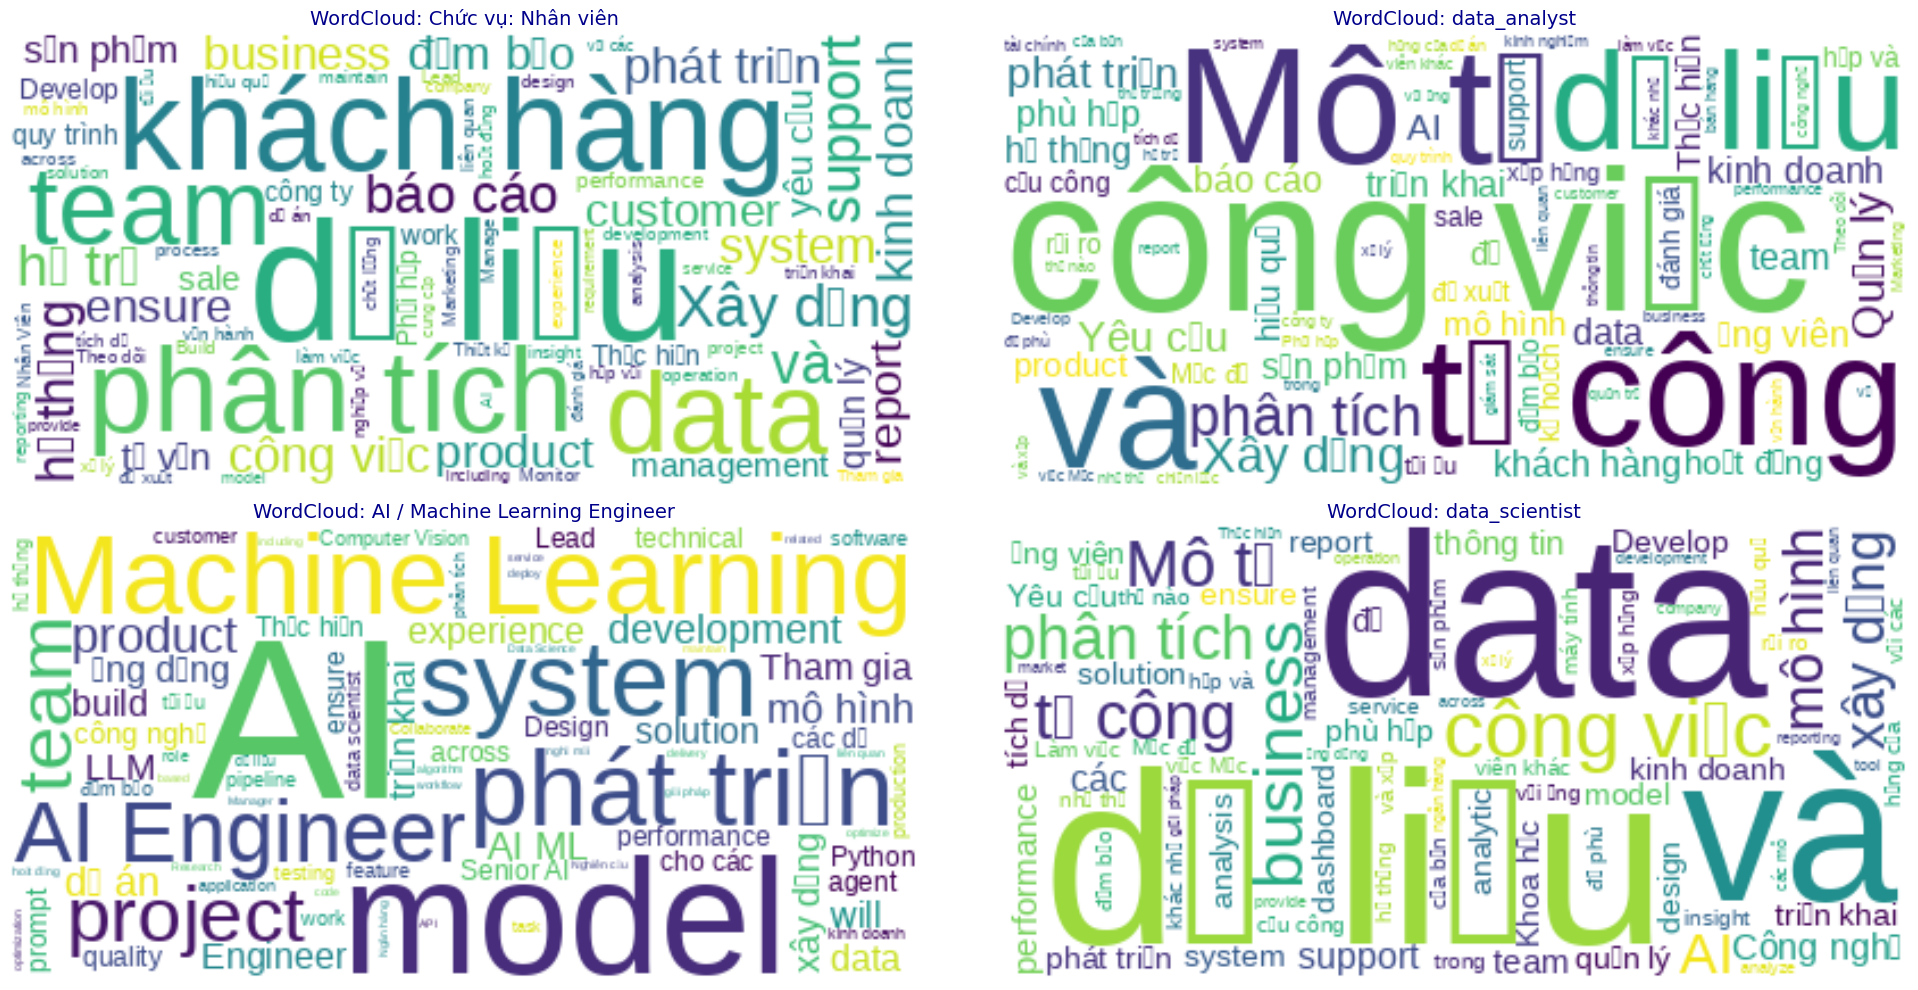

In [14]:
# --- PHẦN 3: ĐỌC VÀ XỬ LÝ DỮ LIỆU ĐẦU VÀO ---
print("\n>>> 1. ĐỌC DỮ LIỆU & EDA...")

try:
    df = pd.read_excel('/content/drive/My Drive/baibaokhoahoc/data_science_jobs.xlsx')
except FileNotFoundError:
    print(" LỖI: Không tìm thấy file dữ liệu. Hãy upload file 'data_science_jobs.xlsx' lên Colab!")
    raise

# Tạo cột Input
df['text_input'] = df['Tiêu đề'].fillna('') + " : " + df['Mô tả công việc'].fillna('')
df['label'] = df['Chuyên môn']
df = df.dropna(subset=['label', 'text_input'])

# LỌC DỮ LIỆU (Giữ nhóm >= 3 bài đăng)
min_count = 3
label_counts = df['label'].value_counts()
valid_labels = label_counts[label_counts >= min_count].index
df_filtered = df[df['label'].isin(valid_labels)].copy()

print(f"   - Tổng số mẫu ban đầu: {len(df)}")
print(f"   - Số mẫu sau khi lọc: {len(df_filtered)}")

# --- TRỰC QUAN HÓA 1: PHÂN BỐ CÔNG VIỆC ---
plt.figure(figsize=(10, 6))
sns.countplot(y=df_filtered['label'], order=df_filtered['label'].value_counts().index, palette='viridis')
plt.title('Phân bố số lượng bài đăng theo vị trí (Sau khi lọc)', fontsize=15)
plt.xlabel('Số lượng')
plt.show()

# --- TRỰC QUAN HÓA 2: MULTI-WORDCLOUD (ĐÃ FIX LỖI) ---
print("   - Đang vẽ WordCloud cho Top 4 nhóm ngành...")
top_labels = df_filtered['label'].value_counts().head(4).index
plt.figure(figsize=(20, 10))

for i, label in enumerate(top_labels):
    subset = df_filtered[df_filtered['label'] == label]
    text_subset = " ".join(subset['text_input'].astype(str).tolist())

    # Dùng biến FONT_PATH đã khai báo ở trên
    wc = WordCloud(width=400, height=200, background_color='white', font_path=FONT_PATH, max_words=80).generate(text_subset)

    plt.subplot(2, 2, i+1)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud: {label}", fontsize=14, color='darkblue')

plt.tight_layout()
plt.show()

In [15]:
# --- PHẦN 4: CHUẨN BỊ TRAINING (BERT) ---
print("\n>>> 2. CHUẨN BỊ DATASET CHO BERT...")

le = LabelEncoder()
df_filtered['label_encoded'] = le.fit_transform(df_filtered['label'])
num_labels = len(le.classes_)

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df_filtered['text_input'].tolist(), df_filtered['label_encoded'].tolist(),
    test_size=0.2, random_state=42, stratify=df_filtered['label_encoded']
)

# --- FIX: Ensure no classes with single members in temp_labels before second split ---
# Convert temp_labels to a pandas Series for easier value counting
temp_labels_series = pd.Series(temp_labels)
class_counts_in_temp = temp_labels_series.value_counts()
# Identify classes with only one member
single_member_classes = class_counts_in_temp[class_counts_in_temp == 1].index

# Filter out samples belonging to single-member classes from temp_texts and temp_labels
filtered_temp_texts = []
filtered_temp_labels = []
for i, label in enumerate(temp_labels):
    if label not in single_member_classes:
        filtered_temp_texts.append(temp_texts[i])
        filtered_temp_labels.append(label)

print(f"   - Ban đầu temp_labels có {len(temp_labels)} mẫu.")
print(f"   - Đã loại bỏ {len(temp_labels) - len(filtered_temp_labels)} mẫu có nhãn chỉ xuất hiện 1 lần trong tập tạm thời.")
print(f"   - Sau khi lọc, temp_labels còn {len(filtered_temp_labels)} mẫu.")

# Use the filtered lists for the second split
val_texts, test_texts, val_labels, test_labels = train_test_split(
    filtered_temp_texts, filtered_temp_labels, test_size=0.5, random_state=42, stratify=filtered_temp_labels
)

MODEL_NAME = 'bert-base-multilingual-cased'
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN = 256

class JobDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts; self.labels = labels
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, item):
        enc = tokenizer(str(self.texts[item]), truncation=True, padding='max_length', max_length=MAX_LEN, return_tensors='pt')
        return {
            'input_ids': enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

train_dataset = JobDataset(train_texts, train_labels)
val_dataset = JobDataset(val_texts, val_labels)
test_dataset = JobDataset(test_texts, test_labels)



>>> 2. CHUẨN BỊ DATASET CHO BERT...
   - Ban đầu temp_labels có 299 mẫu.
   - Đã loại bỏ 8 mẫu có nhãn chỉ xuất hiện 1 lần trong tập tạm thời.
   - Sau khi lọc, temp_labels còn 291 mẫu.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]


>>> 3. BẮT ĐẦU HUẤN LUYỆN MODEL...


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.079700,0.933158,0.793103,0.716361
2,0.903800,0.759741,0.806897,0.730448
3,0.775500,0.717948,0.806897,0.730448



>>> 4. VẼ BIỂU ĐỒ TRAINING LOSS...


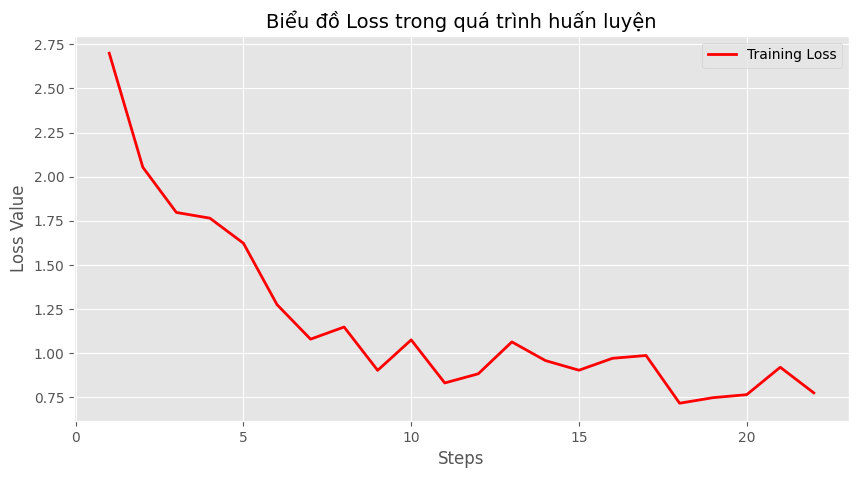

In [16]:
# --- PHẦN 5: TRAINING ---
print("\n>>> 3. BẮT ĐẦU HUẤN LUYỆN MODEL...")
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {'accuracy': accuracy_score(labels, preds), 'f1': f1_score(labels, preds, average='weighted')}

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none",
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=model, args=training_args, train_dataset=train_dataset, eval_dataset=val_dataset, compute_metrics=compute_metrics
)

trainer.train()

# --- TRỰC QUAN HÓA 3: TRAINING LOSS ---
print("\n>>> 4. VẼ BIỂU ĐỒ TRAINING LOSS...")
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
steps = range(1, len(train_loss) + 1)

plt.figure(figsize=(10, 5))
plt.plot(steps, train_loss, label='Training Loss', color='red', linewidth=2)
plt.title('Biểu đồ Loss trong quá trình huấn luyện', fontsize=14)
plt.xlabel('Steps')
plt.ylabel('Loss Value')
plt.legend()
plt.show()


>>> 5. ĐÁNH GIÁ TRÊN TẬP TEST...



--- BÁO CÁO KẾT QUẢ CHI TIẾT ---
                                precision    recall  f1-score   support

AI / Machine Learning Engineer       0.44      1.00      0.62         8
             Backend Developer       0.00      0.00      0.00         1
              Business Analyst       0.00      0.00      0.00         1
            Chức vụ: Nhân viên       0.88      1.00      0.94        69
              Chức vụ: Quản lý       0.00      0.00      0.00         5
        Chức vụ: Thực tập sinh       0.00      0.00      0.00         4
                  Data Analyst       0.00      0.00      0.00         2
                 Data Engineer       0.00      0.00      0.00         2
                Data Scientist       0.00      0.00      0.00         4
                  data_analyst       0.80      1.00      0.89        40
                data_scientist       0.00      0.00      0.00         6
                   ml_engineer       0.00      0.00      0.00         4

                      accura

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


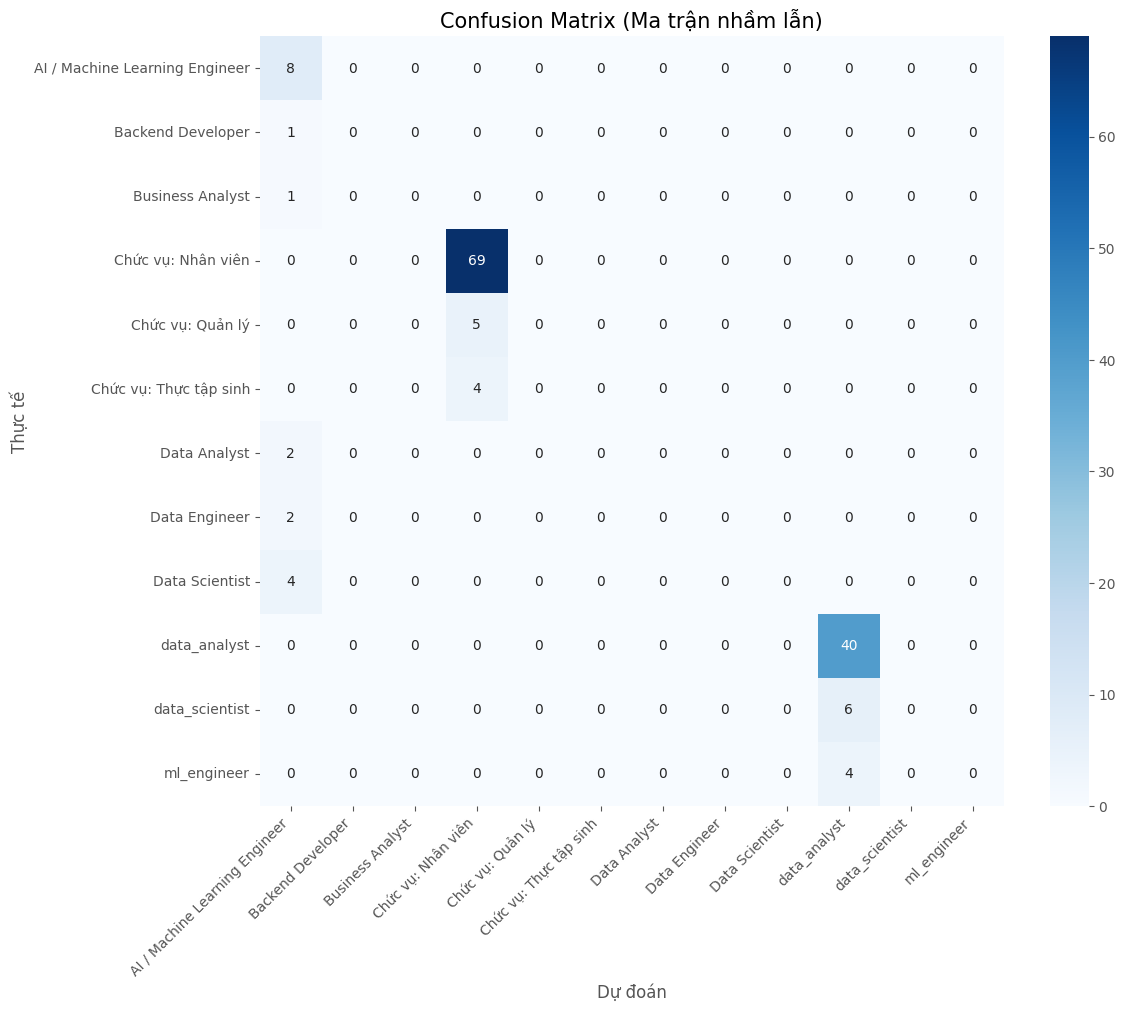

In [18]:
# --- PHẦN 6: ĐÁNH GIÁ ---
print("\n>>> 5. ĐÁNH GIÁ TRÊN TẬP TEST...")
preds_output = trainer.predict(test_dataset)
y_preds = np.argmax(preds_output.predictions, axis=1)
y_true = preds_output.label_ids

print("\n--- BÁO CÁO KẾT QUẢ CHI TIẾT ---")
# Get the unique labels actually present in the test set
unique_labels_in_test_set = np.unique(y_true)
# Filter le.classes_ to include only the names of labels present in the test set
actual_target_names = le.classes_[unique_labels_in_test_set]
print(classification_report(y_true, y_preds, target_names=actual_target_names, labels=unique_labels_in_test_set))

# --- TRỰC QUAN HÓA 4: HEATMAP ---
cm = confusion_matrix(y_true, y_preds, labels=unique_labels_in_test_set) # Also pass labels to confusion_matrix for consistency
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=actual_target_names, yticklabels=actual_target_names)
plt.title('Confusion Matrix (Ma trận nhầm lẫn)', fontsize=15)
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.xticks(rotation=45, ha='right')
plt.show()


>>> 6. PHÂN TÍCH NÂNG CAO (CLUSTERING & SALARY)...


/tmp/ipython-input-512999172.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_skills_salary.values, y=top_skills_salary.index, palette='magma')


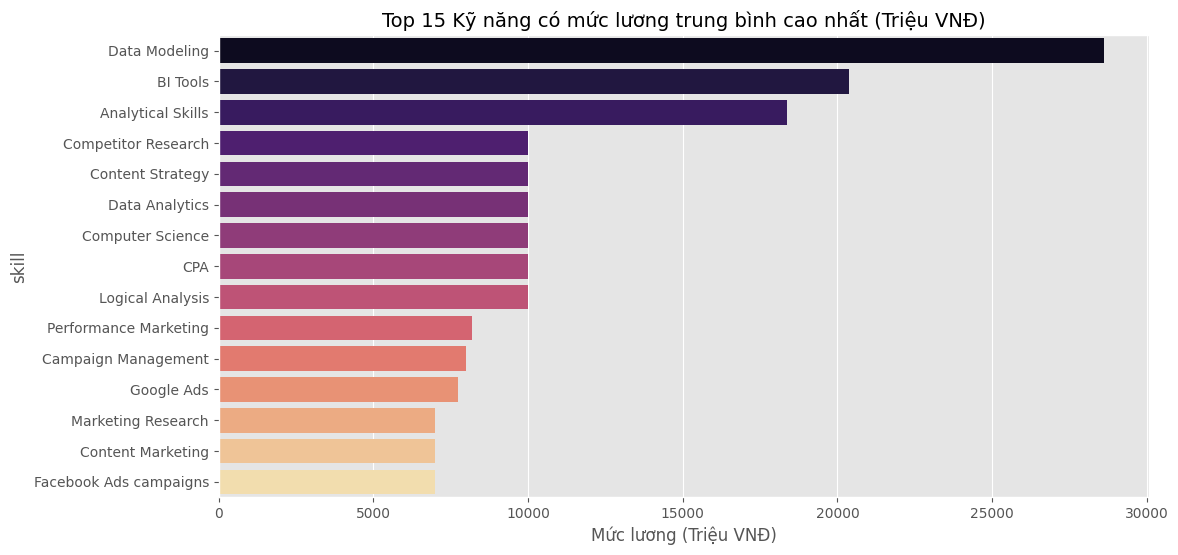

In [19]:
# --- PHẦN 7: PHÂN TÍCH NÂNG CAO ---
print("\n>>> 6. PHÂN TÍCH NÂNG CAO (CLUSTERING & SALARY)...")

# A. PHÂN TÍCH LƯƠNG
def parse_salary(salary_str):
    if pd.isna(salary_str) or 'Thương lượng' in str(salary_str): return None
    s = str(salary_str).lower().replace(',', '')
    try:
        nums = [float(n) for n in re.findall(r'\d+', s)]
        if not nums: return None
        avg = sum(nums)/len(nums)
        return avg * (25/1000000) if 'usd' in s else avg
    except: return None

df_salary = df.copy()
df_salary['salary_clean'] = df_salary['Lương'].apply(parse_salary)
df_salary = df_salary.dropna(subset=['salary_clean'])

if len(df_salary) > 0:
    df_skills = df_salary.assign(skill=df_salary['Kỹ năng'].str.split(',')).explode('skill')
    df_skills['skill'] = df_skills['skill'].str.strip()
    top_skills_salary = df_skills.groupby('skill')['salary_clean'].mean().sort_values(ascending=False).head(15)

    # --- TRỰC QUAN HÓA 5: SALARY BAR CHART ---
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_skills_salary.values, y=top_skills_salary.index, palette='magma')
    plt.title('Top 15 Kỹ năng có mức lương trung bình cao nhất (Triệu VNĐ)', fontsize=14)
    plt.xlabel('Mức lương (Triệu VNĐ)')
    plt.show()

   - Đang chạy K-Means Clustering...


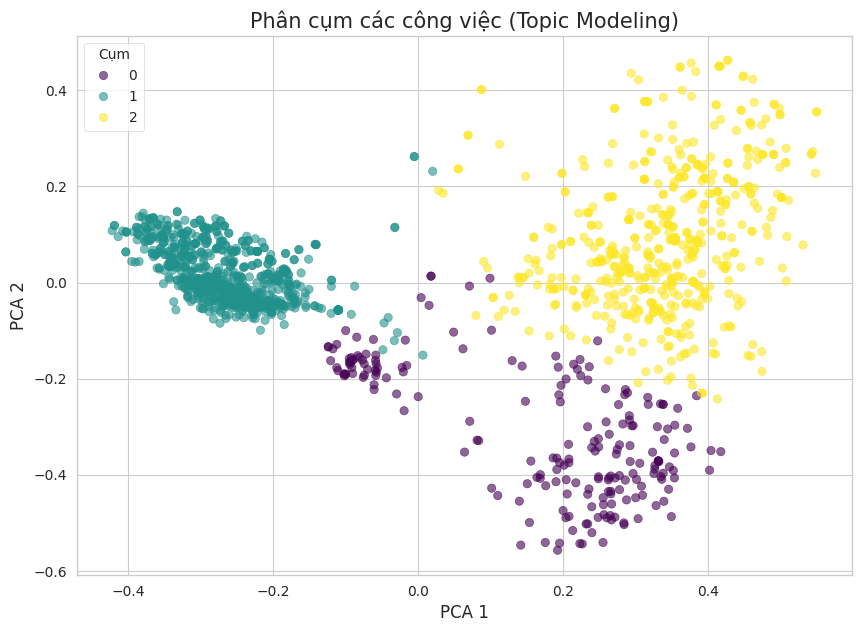

In [23]:
# B. PHÂN CỤM (K-MEANS)
print("   - Đang chạy K-Means Clustering...")
tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['text_input'])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(tfidf_matrix)

# Add the cluster labels to the main DataFrame
df['cluster'] = clusters

pca = PCA(n_components=2)
coords = pca.fit_transform(tfidf_matrix.toarray())

# --- TRỰC QUAN HÓA 6: CLUSTERING SCATTER ---
plt.figure(figsize=(10, 7))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.title('Phân cụm các công việc (Topic Modeling)', fontsize=15)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(*scatter.legend_elements(), title="Cụm")
plt.show()

In [25]:
import pandas as pd
import re

# Hàm làm sạch lương
def clean_salary(salary_str):
    if pd.isna(salary_str) or 'thỏa thuận' in str(salary_str).lower():
        return None  # Bỏ qua lương thỏa thuận

    # Chuyển hết về chữ thường
    s = str(salary_str).lower().replace(',', '').replace('.', '')

    # Tìm các con số trong chuỗi
    numbers = re.findall(r'\d+', s)
    numbers = [int(n) for n in numbers]

    if not numbers:
        return None

    # Xử lý đơn vị tiền tệ (USD -> VNĐ)
    rate = 25000 if 'usd' in s or '$' in s else 1 # Tỷ giá giả định 1 USD = 25k

    # Tính trung bình (Ví dụ: "10-20 triệu" -> lấy 15)
    avg_salary = sum(numbers) / len(numbers)

    # Nếu số quá nhỏ (vd: 1000 USD), nhân tỷ giá
    # Nếu số là triệu (vd: 15), giữ nguyên. Nếu là đồng (15000000), chia về triệu
    if avg_salary < 100:
        if rate > 1: return avg_salary * rate / 1000000 # USD -> Triệu
        return avg_salary # Đã là triệu
    elif avg_salary > 500000: # Đơn vị là đồng
        return avg_salary / 1000000

    return avg_salary

# --- ÁP DỤNG VÀO DỮ LIỆU CỦA BẠN ---
# Giả sử bảng dữ liệu của bạn tên là 'df' và cột lương tên là 'salary'
# df['salary_clean'] = df['salary'].apply(clean_salary)
# df = df.dropna(subset=['salary_clean']) # Bỏ các dòng không có lương

/tmp/ipython-input-3182165305.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='salary_clean', data=plot_df, palette="Set2")


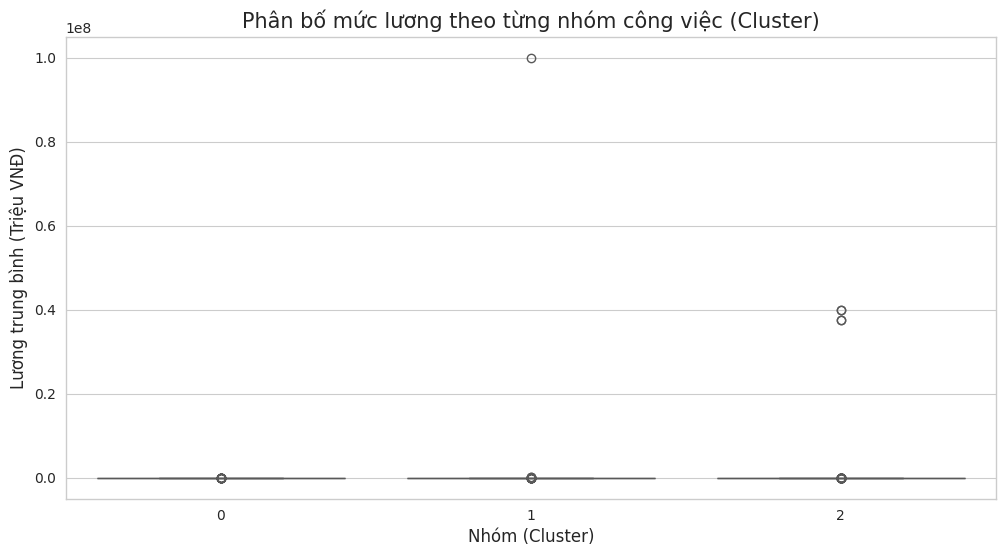

         count           mean           std       min   25%   50%     75%  \
cluster                                                                     
0        155.0      58.439247  1.983803e+02  2.333333  10.0  17.5    30.0   
1        182.0  552151.144238  7.412316e+06  0.000000   3.0  32.5  1100.0   
2        169.0  917597.985944  5.911151e+06  0.027500  16.0  25.0    65.0   

                 max  
cluster               
0             2000.0  
1        100000000.0  
2         40000000.0  


In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cấu hình giao diện
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Prepare a DataFrame for plotting that contains both 'cluster' and 'salary_clean'
# df now has 'cluster' (from previous cell)
# df_salary has 'salary_clean' (from cell -gbGaXTLnsTo)
# Merge df (which now has 'cluster') with df_salary to get 'salary_clean' aligned
plot_df = df.copy() # Make a copy of df, which now includes the 'cluster' column
plot_df = plot_df.merge(df_salary[['salary_clean']], how='left', left_index=True, right_index=True)
plot_df = plot_df.dropna(subset=['salary_clean']) # Keep only rows with valid salary data

# 1. Biểu đồ hộp (Boxplot) - So sánh lương giữa các nhóm công việc
# Giúp bạn biết nhóm nào "giàu" nhất và biên độ lương ra sao
sns.boxplot(x='cluster', y='salary_clean', data=plot_df, palette="Set2")

plt.title('Phân bố mức lương theo từng nhóm công việc (Cluster)', fontsize=15)
plt.xlabel('Nhóm (Cluster)', fontsize=12)
plt.ylabel('Lương trung bình (Triệu VNĐ)', fontsize=12)
plt.show()

# 2. Xem thống kê cụ thể bằng số
print(plot_df.groupby('cluster')['salary_clean'].describe())